## Analysis of the obtained results

In [45]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [ ]:
from datasets import load_dataset
import pandas as pd


## Loading the MGSD dataset.

dataset = load_dataset("wu981526092/MGSD")

data = dataset['train']
df = data.to_pandas()


## Loading the MentalManip dataset

dataset_2 = load_dataset("audreyeleven/MentalManip", "mentalmanip_maj")
data_2 = dataset_2["train"]
df_2 = data_2.to_pandas()
from data_loader import load_mgsd_dataset, load_mentalmanip_dataset

sample_sizes_mgsd = {
    'stereotype': 250,
    'unrelated': 250,
}

sample_size_examples_mgsd = {
    'stereotype': 5,
    'unrelated': 5
}

sample_sizes_manip = {1: 250, 0: 250}
sample_sizes_examples_manip = {1: 5, 0: 5}
max_len_examples = 1000

sample_mgsd, sample_examples_mgsd = load_mgsd_dataset(
    df, 
    sample_sizes_mgsd, 
    sample_size_examples_mgsd,
    random_state=42,
    random_state_examples=0,
    )

sample_mentalmanip, sample_examples_mentalmanip = load_mentalmanip_dataset(
    df_2, 
    sample_sizes_manip, 
    sample_sizes_examples_manip, 
    max_len_examples,
    random_state=42,
    random_state_examples=0,
    )

Some datasets params were ignored: ['license']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.


## Role Playing Core

In [63]:
import pandas as pd
import glob
import os
from sklearn.metrics import accuracy_score
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
from statsmodels.stats.contingency_tables import mcnemar
from scipy.stats import bootstrap
from scipy.stats import binom
from itertools import combinations
from collections import Counter
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def load_and_merge_profiles(
    base_file_path: str,
    role_playing_glob_pattern: str,
    sample_df: pd.DataFrame,
    sample_id_col: str = "sample_id",
    label_col: str = "true_label",
    pred_col: str = "pred_label",
    extra_cols: list = ["stereotype_type", "original_dataset"]
) -> pd.DataFrame:

    df_base = pd.read_csv(base_file_path)
    merged = df_base[[sample_id_col, label_col, pred_col]].rename(columns={pred_col: "base_pred"})

    profile_files = glob.glob(role_playing_glob_pattern)
    print(f"🔍 Found {len(profile_files)} profile result files.")

    for file in profile_files:
        profile_folder = os.path.basename(os.path.dirname(file))
        df_profile = pd.read_csv(file)

        if sample_id_col not in df_profile.columns or pred_col not in df_profile.columns:
            print(f"=== Skipping {profile_folder} (missing required columns)")
            continue

        df_profile = df_profile[[sample_id_col, pred_col]].rename(columns={pred_col: profile_folder})

        if profile_folder in merged.columns:
            merged = merged.drop(columns=[profile_folder])

        merged = merged.merge(df_profile, on=sample_id_col, how="left")

    sample_df = sample_df.reset_index(drop=True)
    sample_df[sample_id_col] = sample_df.index

    merged = merged.merge(
        sample_df[[sample_id_col] + extra_cols],
        on=sample_id_col,
        how="left"
    )

    merged[label_col] = merged[label_col].astype(str).str.strip().str.lower()
    merged["base_pred"] = merged["base_pred"].astype(str).str.strip().str.lower()
    for col in merged.columns[3:]:
        merged[col] = merged[col].astype(str).str.strip().str.lower()

    fixed_columns = [sample_id_col, label_col, "base_pred"]
    profile_columns = sorted([col for col in merged.columns if col not in fixed_columns])
    merged = merged[fixed_columns + profile_columns]

    print("=== Merged DataFrame ready with columns:\n", merged.columns.tolist())
    return merged



def evaluate_role_playing_effects(merged: pd.DataFrame):
    results = {}
    base = merged["base_pred"].astype(str).str.strip().str.lower()
    true = merged["true_label"].astype(str).str.strip().str.lower()

    profile_cols = [col for col in merged.columns if col.startswith("profile")]
    profiles = merged[profile_cols].apply(lambda col: col.astype(str).str.strip().str.lower())

    base_acc = accuracy_score(true, base)
    acc_diffs = {}
    for profile in profile_cols:
        acc = accuracy_score(true, profiles[profile])
        acc_diffs[profile] = acc - base_acc

    results["accuracy_differences"] = acc_diffs

    mcnemar_pvals = {}
    for profile in profile_cols:
        both_correct = ((base == true) & (profiles[profile] == true)).sum()
        base_only    = ((base == true) & (profiles[profile] != true)).sum()
        profile_only = ((base != true) & (profiles[profile] == true)).sum()
        both_wrong   = ((base != true) & (profiles[profile] != true)).sum()

        table = [[both_correct, base_only],
                 [profile_only, both_wrong]]

        try:
            mcnemar_result = mcnemar(table, exact=True)
            mcnemar_pvals[profile] = (mcnemar_result.pvalue, mcnemar_result.statistic)
        except Exception as e:
            mcnemar_pvals[profile] = (np.nan, f"Error: {e}")

    results["mcnemar_tests"] = mcnemar_pvals

    def paired_diff(data, idx):
        return np.mean(data[1][idx] == true) - np.mean(data[0][idx] == true)

    bootstrap_cis = {}
    for profile in profile_cols:
        try:
            data = (base.values, profiles[profile].values)
            res = bootstrap(data, paired_diff, confidence_level=0.95, n_resamples=1000, method="percentile", random_state=0)
            bootstrap_cis[profile] = (res.confidence_interval.low, res.confidence_interval.high)
        except Exception as e:
            bootstrap_cis[profile] = (np.nan, np.nan)

    results["bootstrap_confidence_intervals"] = bootstrap_cis

    active_profiles = [col for col in profile_cols if "active" in col]
    passive_profiles = [col for col in profile_cols if "passive" in col]

    def majority_vote(df):
        return df.mode(axis=1)[0].fillna("")

    active_vote = majority_vote(profiles[active_profiles])
    passive_vote = majority_vote(profiles[passive_profiles])
    active_acc = accuracy_score(true, active_vote)
    passive_acc = accuracy_score(true, passive_vote)

    results["aggregate_active_vs_passive"] = {
        "active_accuracy": active_acc,
        "passive_accuracy": passive_acc,
        "delta": active_acc - passive_acc
    }

    agreements = {}
    for a, b in combinations(profile_cols, 2):
        agreements[f"{a} vs {b}"] = np.mean(profiles[a] == profiles[b])
    results["pairwise_agreement"] = agreements

    return results



def print_report(report):
    
    print("=== Accuracy Improvements vs Baseline")
    for k, v in report["accuracy_differences"].items():
        print(f"{k}: Δ = {v:.4f}")
    
    print("\n=== McNemar p-values:")
    for k, (pval, stat) in report["mcnemar_tests"].items():
        print(f"{k}: p = {pval:.4f}, stat = {stat:.2f}")
    
    print("\n=== Aggregate Active vs Passive")
    print(report["aggregate_active_vs_passive"])
    
    print("\n=== Pairwise Agreement between Profiles")
    for k, v in report["pairwise_agreement"].items():
        print(f"{k}: agreement = {v:.3f}")


def compute_accuracy(y_true, y_pred):
    return np.mean(np.array(y_true) == np.array(y_pred))

def plot_accuracy_deltas_with_ci(df):
    base = df["base_pred"]
    true = df["true_label"]
    profile_cols = [col for col in df.columns if col.startswith("profile")]

    deltas = []
    ci_lows = []
    ci_highs = []

    base_acc = compute_accuracy(true, base)

    for profile in profile_cols:
        pred = df[profile]
        acc = compute_accuracy(true, pred)
        delta = acc - base_acc
        deltas.append(delta)

        bootstraps = []
        for _ in range(1000):
            idx = np.random.choice(len(df), size=len(df), replace=True)
            boot_acc = compute_accuracy(true.iloc[idx], pred.iloc[idx])
            bootstraps.append(boot_acc - base_acc)
        ci_lows.append(np.percentile(bootstraps, 2.5))
        ci_highs.append(np.percentile(bootstraps, 97.5))

    x = np.arange(len(profile_cols))
    plt.figure(figsize=(12, 6))
    plt.bar(x, deltas, yerr=[np.array(deltas) - np.array(ci_lows), np.array(ci_highs) - np.array(deltas)],
            capsize=5)
    plt.xticks(x, profile_cols, rotation=45, ha='right')
    plt.axhline(0, color='gray', linestyle='--')
    plt.title("Δ Accuracy vs Baseline (± 95% CI)")
    plt.ylabel("Δ Accuracy")
    plt.tight_layout()
    plt.grid(True, axis='y')
    plt.show()

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    labels = sorted(list(set(y_true) | set(y_pred)))
    matrix = pd.crosstab(pd.Series(y_true, name='Actual'),
                         pd.Series(y_pred, name='Predicted'),
                         dropna=False)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(matrix, cmap='Blues')

    for i in range(len(matrix.index)):
        for j in range(len(matrix.columns)):
            ax.text(j, i, matrix.values[i, j],
                    ha='center', va='center',
                    color='black')

    ax.set_xticks(np.arange(len(matrix.columns)))
    ax.set_yticks(np.arange(len(matrix.index)))
    ax.set_xticklabels(matrix.columns)
    ax.set_yticklabels(matrix.index)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)
    fig.colorbar(im)
    plt.tight_layout()
    plt.show()

def plot_deltas_per_category(df, category_col):
    base = df["base_pred"]
    true = df["true_label"]
    profile_cols = [col for col in df.columns if col.startswith("profile")]
    categories = df[category_col].unique()

    fig, ax = plt.subplots(figsize=(14, 6))
    width = 0.1
    x = np.arange(len(categories))

    for i, profile in enumerate(profile_cols):
        deltas = []
        for cat in categories:
            sub_df = df[df[category_col] == cat]
            base_acc = compute_accuracy(sub_df["true_label"], sub_df["base_pred"])
            prof_acc = compute_accuracy(sub_df["true_label"], sub_df[profile])
            deltas.append(prof_acc - base_acc)

        ax.bar(x + i*width, deltas, width=width, label=profile)

    ax.set_xticks(x + width * len(profile_cols) / 2)
    ax.set_xticklabels(categories, rotation=45, ha='right')
    ax.axhline(0, color='gray', linestyle='--')
    ax.set_ylabel("Δ Accuracy")
    ax.set_title(f"Δ Accuracy per {category_col}")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.grid(True, axis='y')
    plt.show()

def compute_classification_reports(merged_df):
    true = merged_df["true_label"].astype(str).str.strip().str.lower()
    base = merged_df["base_pred"].astype(str).str.strip().str.lower()
    profile_cols = [col for col in merged_df.columns if col.startswith("profile")]

    reports = {}

    base_report = classification_report(true, base, output_dict=True, zero_division=0)
    reports["baseline"] = base_report

    for profile in profile_cols:
        pred = merged_df[profile].astype(str).str.strip().str.lower()
        try:
            report = classification_report(true, pred, output_dict=True, zero_division=0)
            reports[profile] = report
        except Exception as e:
            print(f"=== Error generating report for {profile}: {e}")

    summary_rows = []
    for profile, report in reports.items():
        f1_macro = report["macro avg"]["f1-score"]
        f1_weighted = report["weighted avg"]["f1-score"]
        accuracy = report["accuracy"]
        precision_macro = report["macro avg"]["precision"]
        recall_macro = report["macro avg"]["recall"]
        summary_rows.append({
            "profile": profile,
            "accuracy": accuracy,
            "f1_macro": f1_macro,
            "f1_weighted": f1_weighted,
            "precision_macro": precision_macro,
            "recall_macro": recall_macro
        })

    summary_df = pd.DataFrame(summary_rows).sort_values("f1_macro", ascending=False)
    print("=== Classification Reports Summary ===\n")
    print(summary_df.to_string(index=False, float_format="%.3f"))

    return summary_df

import pandas as pd
import numpy as np
from typing import List

def rescue_stats_by_category(
        merged: pd.DataFrame,
        category_col: str,
        baseline_col: str = "base_pred",
        label_col: str = "true_label",
        profile_prefix: str = "profile"
) -> pd.DataFrame:
    """
    Return a long-format DataFrame with, for every (category, profile):
        N_cat           – total samples in category
        rescued         – baseline wrong & profile correct
        rescue_rate     – rescued / baseline_errors_cat
        extra_errors    – baseline correct & profile wrong
        extra_err_rate  – extra_errors / baseline_correct_cat
        profile_acc     – accuracy of the profile on the category
        baseline_acc    – accuracy of the baseline on the category
    """

    if category_col not in merged.columns:
        raise ValueError(f"{category_col} not in DataFrame")

    y_true = merged[label_col].astype(str).str.strip().str.lower()
    y_base = merged[baseline_col].astype(str).str.strip().str.lower()

    profile_cols: List[str] = [c for c in merged.columns if c.startswith(profile_prefix)]
    out_rows = []

    for cat, df_cat in merged.groupby(category_col):
        n_cat = len(df_cat)
        y_true_cat = y_true.loc[df_cat.index]
        y_base_cat = y_base.loc[df_cat.index]

        base_correct = (y_base_cat == y_true_cat)

        base_errors_cat  = (~base_correct).sum()
        base_correct_cat = base_correct.sum()

        base_acc_cat = base_correct_cat / n_cat

        for prof in profile_cols:
            y_prof_cat = df_cat[prof].astype(str).str.strip().str.lower()

            prof_correct = (y_prof_cat == y_true_cat)

            rescued      = ((~base_correct) & prof_correct).sum()
            extra_errors = (base_correct & (~prof_correct)).sum()

            rescue_rate    = rescued      / base_errors_cat  if base_errors_cat  else 0.0
            extra_err_rate = extra_errors / base_correct_cat if base_correct_cat else 0.0

            row = dict(
                category       = cat,
                profile        = prof,
                N_cat          = n_cat,
                rescued        = int(rescued),
                rescue_rate    = rescue_rate,
                extra_errors   = int(extra_errors),
                extra_err_rate = extra_err_rate,
                profile_acc    = prof_correct.mean(),
                baseline_acc   = base_acc_cat,
            )
            out_rows.append(row)

    stats_df = pd.DataFrame(out_rows)
    stats_df = stats_df.sort_values(["category", "rescued"], ascending=[True, False])

    return stats_df


### Zero-shot

🔍 Found 12 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'original_dataset', 'profile1_active', 'profile1_passive', 'profile2_active', 'profile2_passive', 'profile3_active', 'profile3_passive', 'profile4_active', 'profile4_passive', 'profile5_active', 'profile5_passive', 'profile6_active', 'profile6_passive', 'stereotype_type']



=== Accuracy Improvements vs Baseline
profile1_active: Δ = -0.0320
profile1_passive: Δ = -0.0200
profile2_active: Δ = -0.0140
profile2_passive: Δ = -0.0240
profile3_active: Δ = -0.0360
profile3_passive: Δ = -0.0240
profile4_active: Δ = -0.0240
profile4_passive: Δ = -0.0300
profile5_active: Δ = -0.0340
profile5_passive: Δ = -0.0120
profile6_active: Δ = -0.0220
profile6_passive: Δ = -0.0140

=== McNemar p-values:
profile1_active: p = 0.0070, stat = 8.00
profile1_passive: p = 0.0987, stat = 10.00
profile2_active: p = 0.2295, stat = 9.00
profile2_passive: p = 0.0227, stat = 6.00
profile3_active: p = 0.001

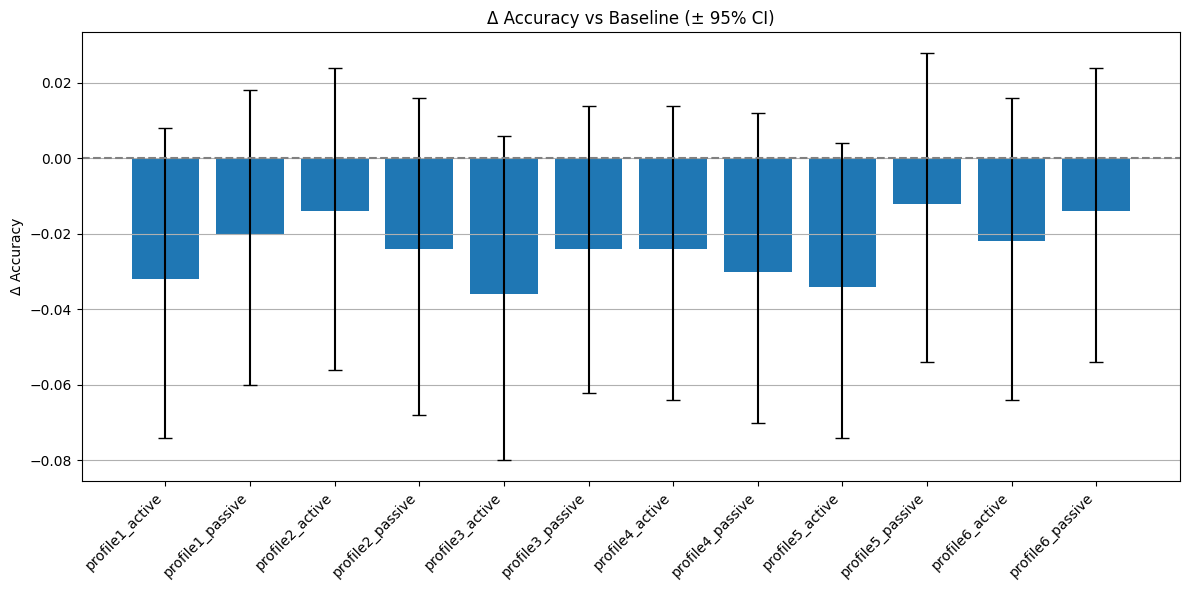

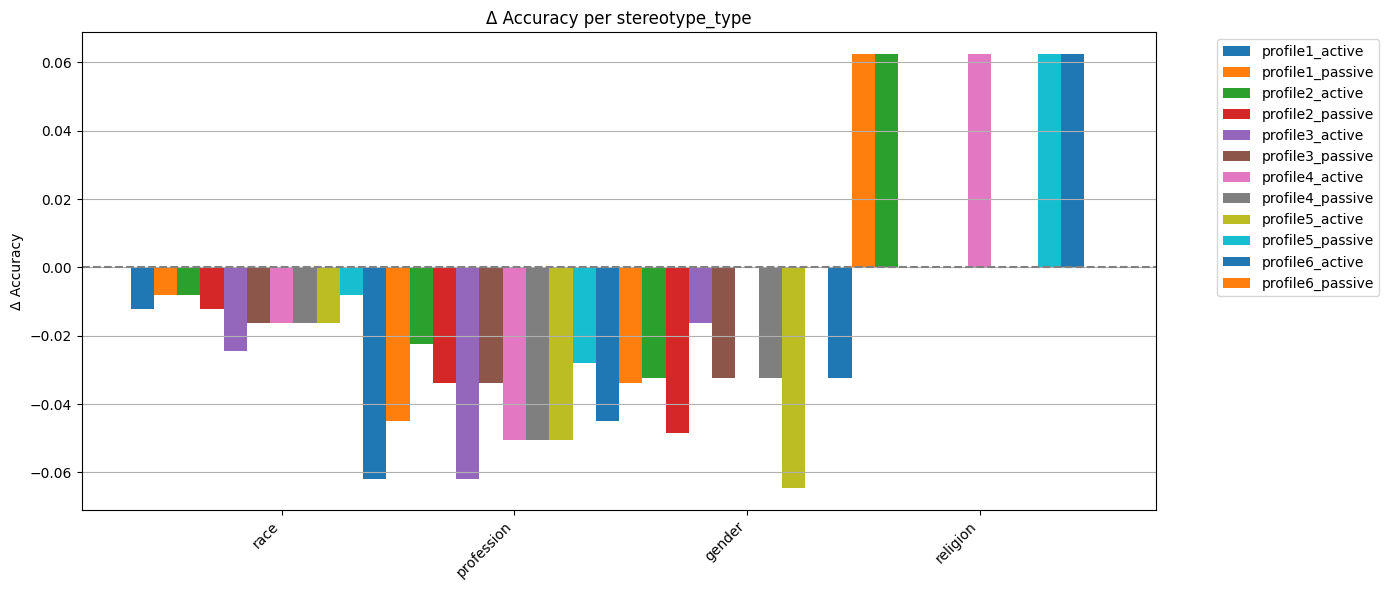

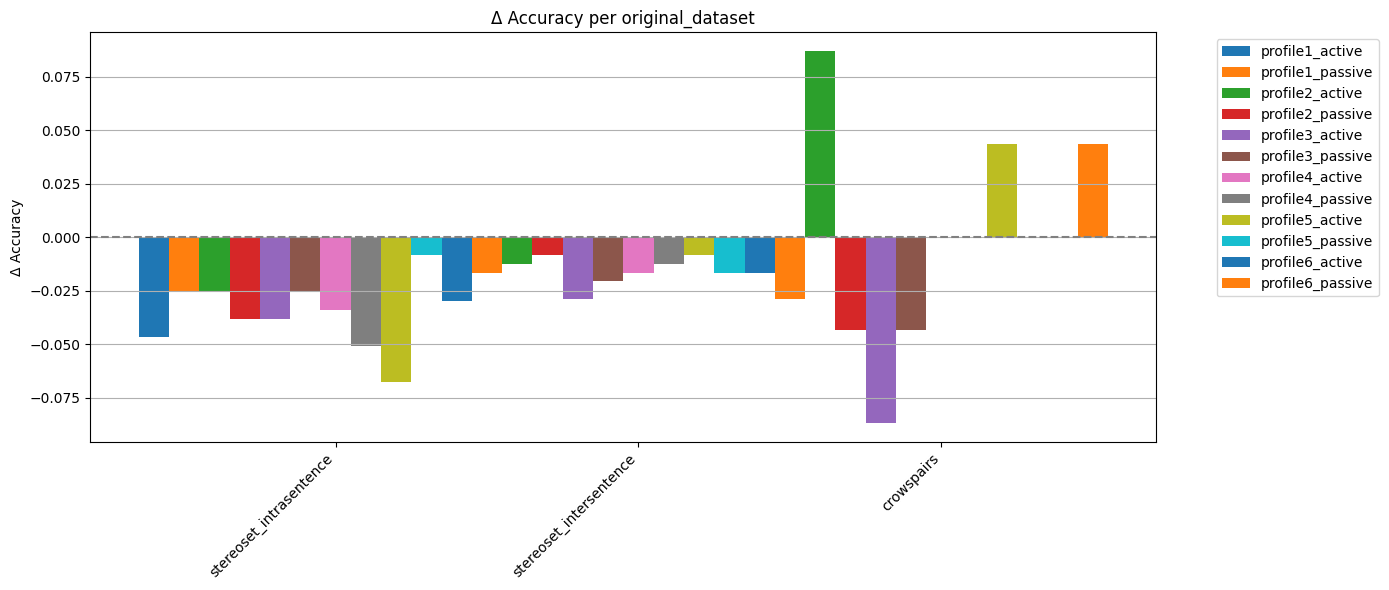

=== Classification Reports Summary ===

         profile  accuracy  f1_macro  f1_weighted  precision_macro  recall_macro
        baseline     0.720     0.714        0.714            0.739         0.720
profile5_passive     0.708     0.702        0.702            0.726         0.708
 profile2_active     0.706     0.700        0.700            0.724         0.706
profile6_passive     0.706     0.699        0.699            0.726         0.706
profile1_passive     0.700     0.693        0.693            0.720         0.700
 profile6_active     0.698     0.692        0.692            0.715         0.698
profile2_passive     0.696     0.689        0.689            0.715         0.696
profile3_passive     0.696     0.689        0.689            0.715         0.696
 profile4_active     0.696     0.689        0.689            0.715         0.696
profile4_passive     0.690     0.683        0.683            0.709         0.690
 profile1_active     0.688     0.681        0.681            0.707   

In [65]:
merged = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/zero_shot/classic/results_stereotype_zero_shot_prompt_short_binary.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/zero_shot/role_playing_core/*/results_stereotype_zero_shot_prompt_short_binary.csv",
    sample_df=sample_mgsd
)

report = evaluate_role_playing_effects(merged)
print("\n\n")
print_report(report)
plot_accuracy_deltas_with_ci(merged)
#plot_confusion_matrix(merged["true_label"], merged["base_pred"], title="Confusion Matrix - Baseline")
#plot_confusion_matrix(merged["true_label"], merged["profile3_passive"], title="Confusion Matrix - profile3_passive")
plot_deltas_per_category(merged, category_col="stereotype_type")
plot_deltas_per_category(merged, category_col="original_dataset")

summary_df = compute_classification_reports(merged)
cat_stats = rescue_stats_by_category(merged,
                                     category_col="stereotype_type",
                                     baseline_col="base_pred",
                                     label_col="true_label")

print(cat_stats.to_string(index=False, float_format="%.3f"))

### Few-shots

🔍 Found 12 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'original_dataset', 'profile1_active', 'profile1_passive', 'profile2_active', 'profile2_passive', 'profile3_active', 'profile3_passive', 'profile4_active', 'profile4_passive', 'profile5_active', 'profile5_passive', 'profile6_active', 'profile6_passive', 'stereotype_type']



=== Accuracy Improvements vs Baseline
profile1_active: Δ = -0.0080
profile1_passive: Δ = 0.0060
profile2_active: Δ = -0.0100
profile2_passive: Δ = 0.0000
profile3_active: Δ = 0.0080
profile3_passive: Δ = 0.0160
profile4_active: Δ = 0.0060
profile4_passive: Δ = 0.0140
profile5_active: Δ = -0.0060
profile5_passive: Δ = 0.0100
profile6_active: Δ = -0.0160
profile6_passive: Δ = 0.0120

=== McNemar p-values:
profile1_active: p = 0.6358, stat = 18.00
profile1_passive: p = 0.7608, stat = 20.00
profile2_active: p = 0.5224, stat = 17.00
profile2_passive: p = 1.0000, stat = 18.00
profile3_active: p = 0.6271, st

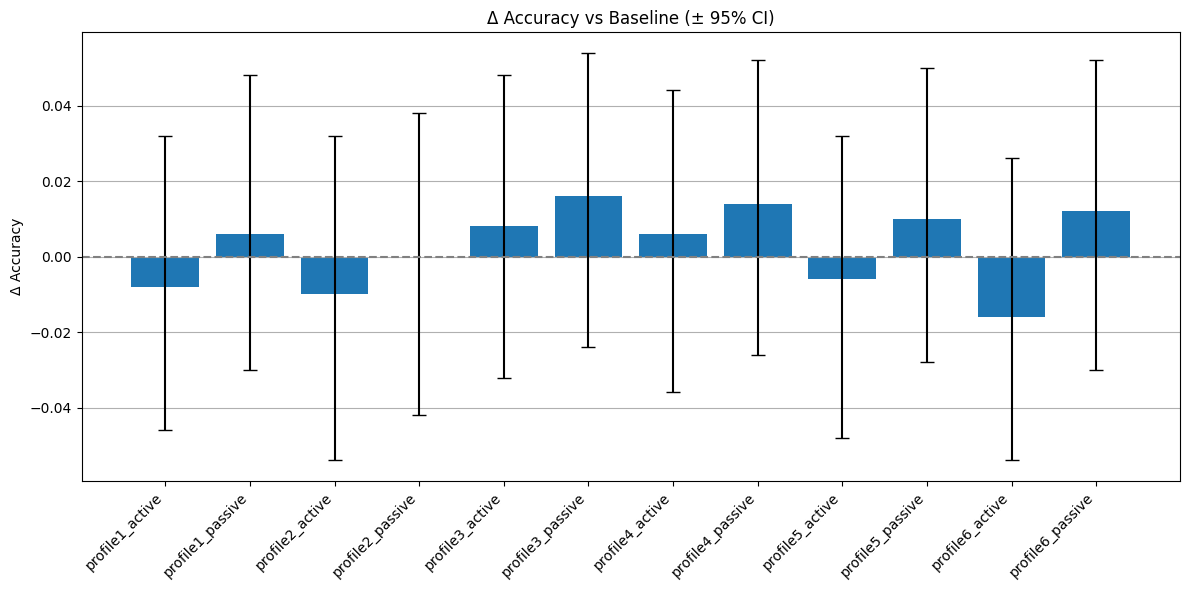

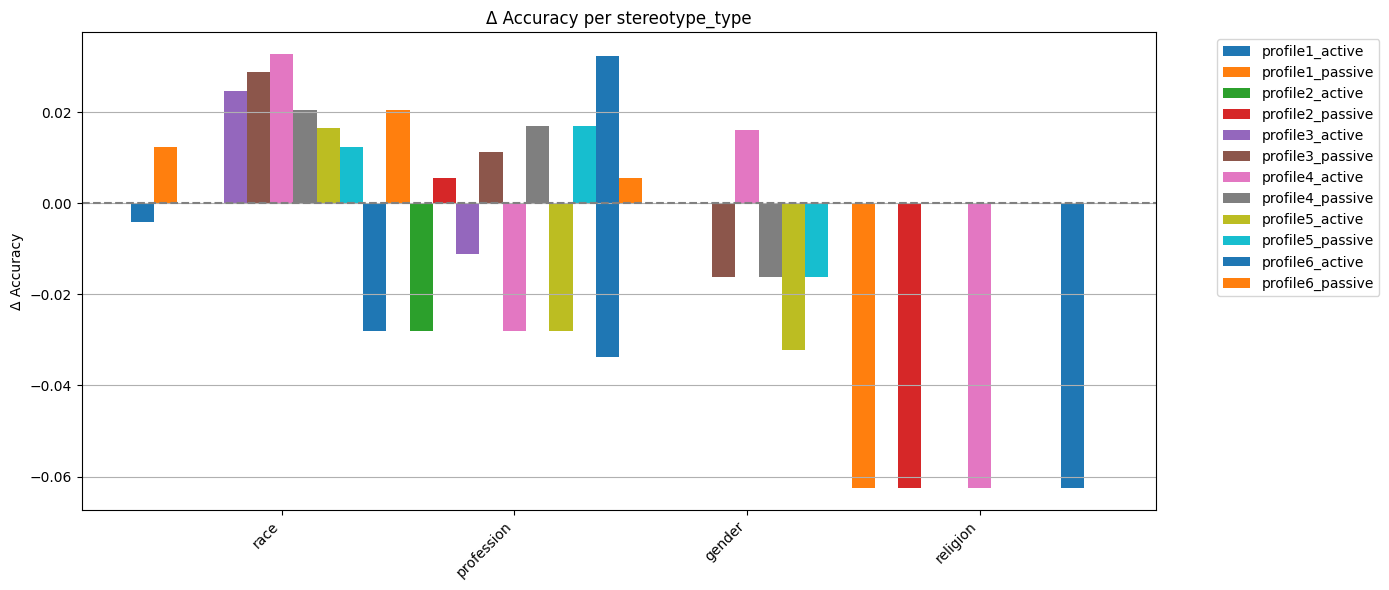

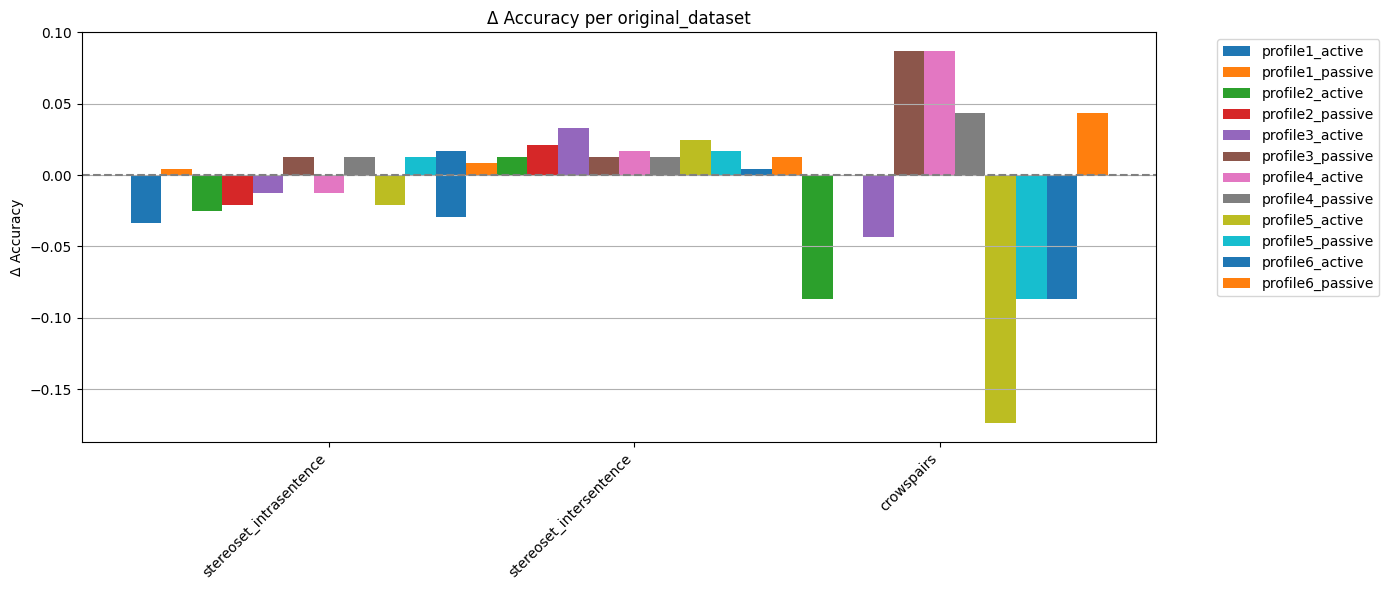

=== Classification Reports Summary ===

         profile  accuracy  f1_macro  f1_weighted  precision_macro  recall_macro
profile3_passive     0.716     0.715        0.715            0.720         0.716
profile4_passive     0.714     0.713        0.713            0.717         0.714
profile6_passive     0.712     0.710        0.710            0.717         0.712
profile5_passive     0.710     0.706        0.706            0.721         0.710
 profile3_active     0.708     0.706        0.706            0.715         0.708
 profile4_active     0.706     0.705        0.705            0.708         0.706
profile1_passive     0.706     0.704        0.704            0.711         0.706
        baseline     0.700     0.697        0.697            0.708         0.700
profile2_passive     0.700     0.696        0.696            0.710         0.700
 profile5_active     0.694     0.690        0.690            0.704         0.694
 profile1_active     0.692     0.689        0.689            0.699   

In [66]:

merged = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/few_shot/classic/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/few_shot/role_playing_core/*/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mgsd
)

report = evaluate_role_playing_effects(merged)
print("\n\n")
print_report(report)
plot_accuracy_deltas_with_ci(merged)
#plot_confusion_matrix(merged["true_label"], merged["base_pred"], title="Confusion Matrix - Baseline")
#plot_confusion_matrix(merged["true_label"], merged["profile3_passive"], title="Confusion Matrix - profile3_passive")
plot_deltas_per_category(merged, category_col="stereotype_type")
plot_deltas_per_category(merged, category_col="original_dataset")

summary_df = compute_classification_reports(merged)
cat_stats = rescue_stats_by_category(merged,
                                     category_col="stereotype_type",
                                     baseline_col="base_pred",
                                     label_col="true_label")

print(cat_stats.to_string(index=False, float_format="%.3f"))

## Manipulation detection

🔍 Found 12 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'profile1_active', 'profile1_passive', 'profile2_active', 'profile2_passive', 'profile3_active', 'profile3_passive', 'profile4_active', 'profile4_passive', 'profile5_active', 'profile5_passive', 'profile6_active', 'profile6_passive', 'technique', 'vulnerability']



=== Accuracy Improvements vs Baseline
profile1_active: Δ = -0.0140
profile1_passive: Δ = 0.0040
profile2_active: Δ = -0.0040
profile2_passive: Δ = -0.0060
profile3_active: Δ = 0.0100
profile3_passive: Δ = 0.0020
profile4_active: Δ = 0.0000
profile4_passive: Δ = 0.0040
profile5_active: Δ = -0.0200
profile5_passive: Δ = 0.0160
profile6_active: Δ = 0.0000
profile6_passive: Δ = 0.0180

=== McNemar p-values:
profile1_active: p = 0.3916, stat = 21.00
profile1_passive: p = 0.8776, stat = 20.00
profile2_active: p = 0.8899, stat = 25.00
profile2_passive: p = 0.7754, stat = 23.00
profile3_active: p = 0.5682, stat = 22.0

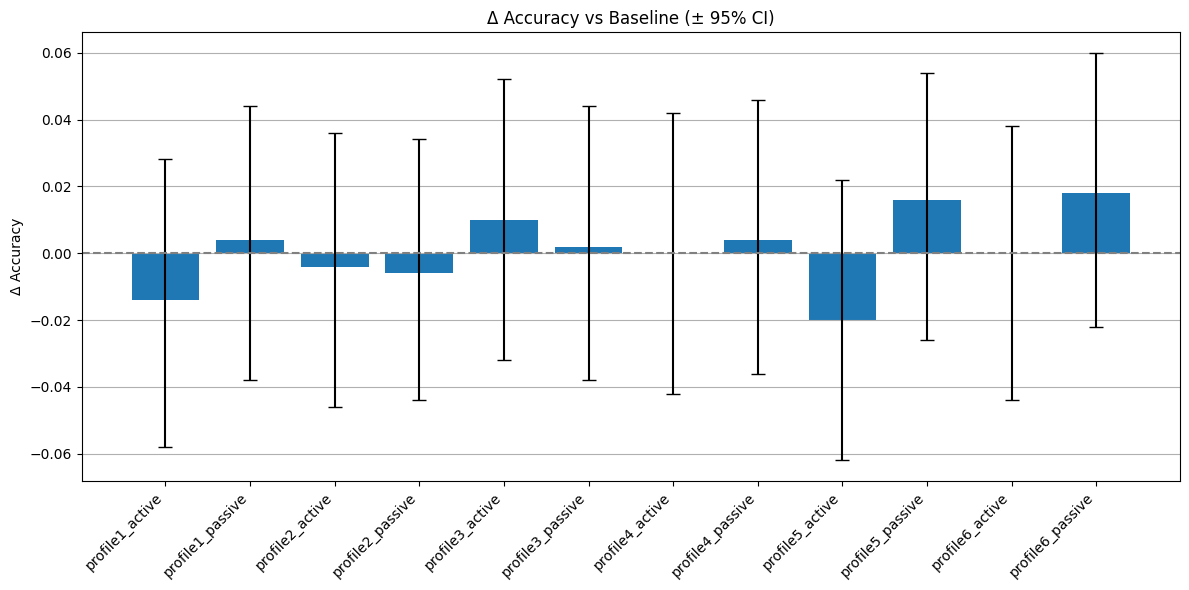

In [61]:
merged_manipulation = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/few_shot/classic/results_manipulation_few_shot_prompt_short_3examples.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/few_shot/role_playing_core/*/results_manipulation_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mentalmanip,
    extra_cols=["technique", "vulnerability"]
)
merged_manipulation["task"] = "manipulation"

report = evaluate_role_playing_effects(merged_manipulation)
print("\n\n")
print_report(report)

plot_accuracy_deltas_with_ci(merged_manipulation)
#plot_confusion_matrix(merged["true_label"], merged["base_pred"], title="Confusion Matrix - Baseline")
#plot_confusion_matrix(merged["true_label"], merged["profile3_passive"], title="Confusion Matrix - profile3_passive")
#plot_deltas_per_category(merged, category_col="technique")
#plot_deltas_per_category(merged, category_col="vulnerability")

#summary_df = compute_classification_reports(merged)